# 14 — 3D terrain reasoning with Astra and GeoLibre

[Launch in JupyterLite](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=14_astra_terrain_3d.ipynb)

Read one synthetic landscape as contours, a slope field, a profile, a rotatable surface and native GeoLibre extrusions. Use Astra to compare what the representations reveal. **Time:** about 25 minutes. **Prerequisites:** array indexing; lab 00.

**Runtime:** browser Python for the analysis; hosted GeoLibre for maps; optional CPython runner for Astra. The default run makes no model calls. The first run needs network access for packages, GeoLibre and interactive Plotly scripts. Static plots and local analysis do not depend on data APIs.

**Learning cycle:** predict → run → compare views → explain → test a different assumption.

## See the connections

![Terrain: 2D, 3D and a profile tell one story: Surface: An analytic terrain uses local metric axes; Derivatives: Slope follows elevation change per metre; 3D maps: GeoLibre extrusions and a rotatable surface; Astra: Compare views without inventing measured terrain](assets/14_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage(["numpy", "pandas", "matplotlib", "scipy", "pillow"])
    import micropip
    await micropip.install(["geolibre==3.0.0", "plotly==6.5.0"])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from geolibre_lite import LiteMap as Map
from cognition import style_plots, COLORS, save_json
from astra_lab import make_request, response_text
style_plots()

## 1. Build a terrain with known units

This surface is an analytic teaching function, **not a DEM of the displayed place**. Local x and y are metres; z is invented elevation in metres. Grid spacing is 100 m. Slope uses the metric spacing, not longitude/latitude degrees.

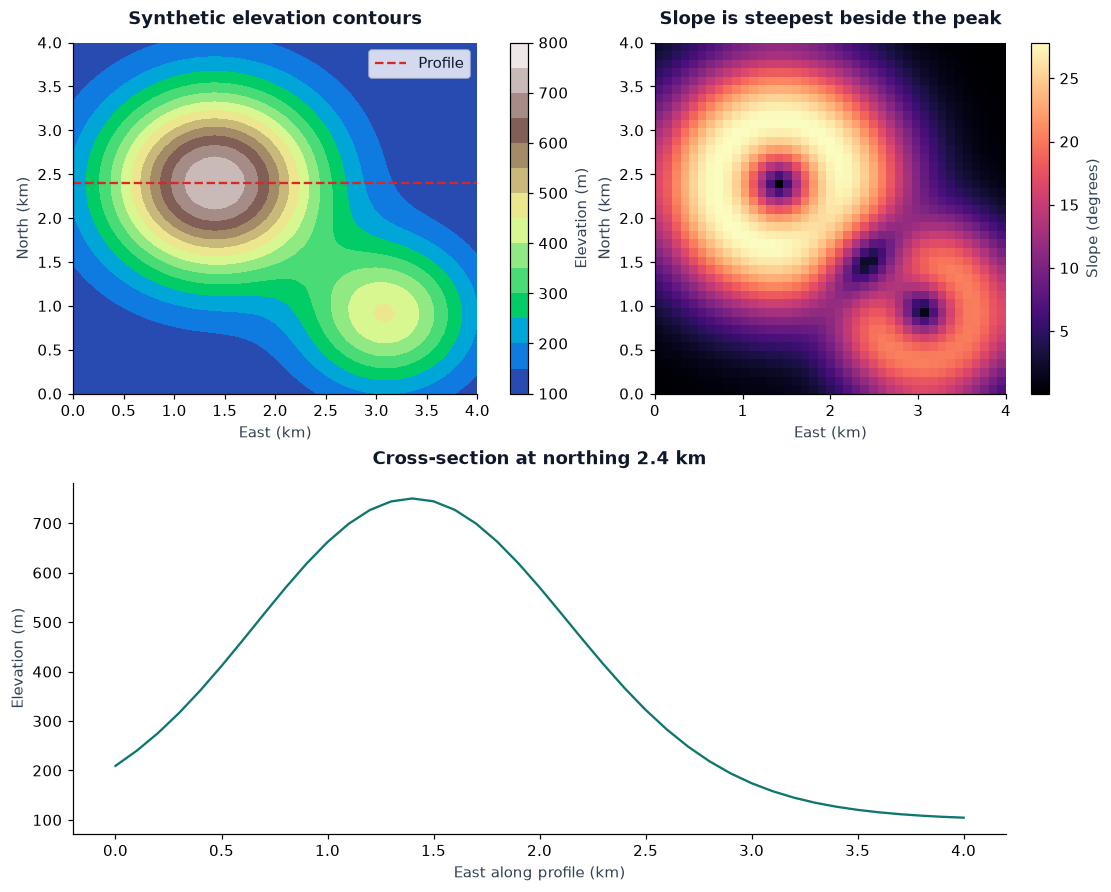

In [2]:
from cognition import grid_features, plotly_view, figure_data_url
import plotly.graph_objects as go
axis_m = np.linspace(0,4000,41)
x, y = np.meshgrid(axis_m,axis_m)
z = 100 + 650*np.exp(-((x-1400)**2+(y-2400)**2)/1_100_000) + 350*np.exp(-((x-3100)**2+(y-900)**2)/650_000)
dzdy, dzdx = np.gradient(z,100,100)
slope = np.degrees(np.arctan(np.hypot(dzdx,dzdy)))
profile_row = 24
fig, panels = plt.subplot_mosaic([["contours","slope"],["profile","profile"]],figsize=(10,8),layout="constrained")
axes = [panels[k] for k in ["contours","slope","profile"]]
contours = axes[0].contourf(x/1000,y/1000,z,levels=12,cmap="terrain")
axes[0].axhline(axis_m[profile_row]/1000,color="#dc2626",ls="--",label="Profile")
axes[0].set(xlabel="East (km)",ylabel="North (km)",title="Synthetic elevation contours")
axes[0].legend()
fig.colorbar(contours,ax=axes[0],label="Elevation (m)")
slopes = axes[1].imshow(slope,origin="lower",extent=(0,4,0,4),cmap="magma")
axes[1].set(xlabel="East (km)",ylabel="North (km)",title="Slope is steepest beside the peak")
fig.colorbar(slopes,ax=axes[1],label="Slope (degrees)")
axes[2].plot(axis_m/1000,z[profile_row],color="#0f766e")
axes[2].set(xlabel="East along profile (km)",ylabel="Elevation (m)",title="Cross-section at northing 2.4 km")
terrain_image = figure_data_url(fig)
plt.show()

## 2. Rotate the landscape, then question the camera

Drag to rotate, scroll to zoom, and use the scale menu to compare vertical exaggeration. The surface has the same units on all three axes. A fixed static 3D view below remains readable when the Plotly CDN is unavailable.

C:\Users\duf2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\display.py:447: UserWarning:

Consider using IPython.display.IFrame instead



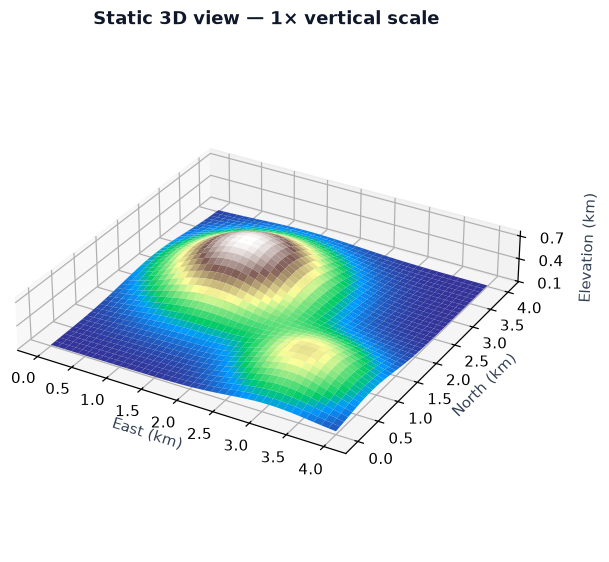

In [3]:
surface = go.Figure(go.Surface(x=x,y=y,z=z,colorscale="Earth",colorbar={"title":"Elevation (m)"}))
surface.update_layout(title="Synthetic terrain — equal metric axes (1×)",height=530,
    scene={"xaxis_title":"East (m)","yaxis_title":"North (m)","zaxis_title":"Elevation (m)",
           "aspectmode":"manual","aspectratio":{"x":1,"y":1,"z":float(np.ptp(z)/4000)}},
    updatemenus=[{"buttons":[{"label":f"{scale}× vertical","method":"relayout","args":[{
        "scene.aspectratio.z":float(np.ptp(z)/4000*scale),"title.text":f"Synthetic terrain — {scale}× vertical exaggeration"}]} for scale in [1,2,4]]}])
display(plotly_view(surface,height=570))
fig = plt.figure(figsize=(10,5),layout="constrained")
ax = fig.add_subplot(projection="3d")
ax.plot_surface(x/1000,y/1000,z/1000,cmap="terrain",linewidth=0)
ax.set(xlabel="East (km)",ylabel="North (km)",zlabel="Elevation (km)",title="Static 3D view — 1× vertical scale")
ax.set_box_aspect((4,4,np.ptp(z)/1000))
ax.set_zticks([.1,.4,.7])
plt.show()

## 3. A genuine GeoLibre 3D map

These columns represent sampled synthetic elevation, not buildings. Heights are in metres; the map uses the GeoLibre 3.0 extrusion fields and a pitched camera. Coarsening to 10 × 10 columns keeps the browser responsive. Use the contour and profile views to resolve occlusion in 3D.

In [4]:
terrain_fc = grid_features(z[2:40:4,2:40:4],field="elevation_m",cell_m=400)
terrain_map = Map(center=(-122.278,37.917),zoom=12.5,height="580px")
terrain_map.add_geojson(terrain_fc,name="Synthetic elevation columns (metres)",
    extrusionEnabled=True,extrusionHeightProperty="elevation_m",extrusionHeightScale=1,
    extrusionColor="#0f766e",extrusionOpacity=.9,fillOpacity=.25,strokeWidth=.5)
terrain_map.set_view(pitch=60,bearing=-25)
display(terrain_map)
save_json("exports/synthetic_terrain.geolibre.json",terrain_map.to_project())

'exports\\synthetic_terrain.geolibre.json'

## 4. Ask Astra to reconcile the views

The evidence includes the actual maximum slope and the profile location, so Astra need not guess measurements from perspective. Ask what can and cannot be inferred about routing or drainage. Neither roads nor a hydrologic model are supplied.

In [5]:
evidence={"evidence_id":"terrain_metrics","source":"analytic synthetic function",
          "grid_spacing_m":100,"min_elevation_m":float(z.min()),"max_elevation_m":float(z.max()),
          "max_slope_degrees":float(slope.max()),"profile_northing_m":2400,
          "profile_max_elevation_m":float(z[profile_row].max()),"crs":"local metric teaching grid"}
request=make_request("Compare contours, slope, and profile. Explain the effect of vertical exaggeration. Which extra data would a defensible route or drainage analysis require? Cite terrain_metrics.",evidence,images=[terrain_image])
save_json("exports/terrain_review_request.json",request)

'exports\\terrain_review_request.json'

## Optional: run this request with GPT-6 Astra

All calculations above run locally. The exported request has **not been sent** and any example plan is **hand-authored**, not a recorded model response. To obtain a live response:

1. Download the generated request from JupyterLite's file browser (right-click → Download).
2. In a full CPython terminal in this repository, set `OPENAI_API_KEY` in that terminal's environment. Never put the key in a notebook, output, or the static site.
3. Preview with `python scripts/run_astra.py PATH_TO_REQUEST.json`. Send deliberately with `--send --output astra_response.json`. This uses your API account and can incur charges.
4. Upload `astra_response.json` to the notebook folder, set the import path in the next cell, and rerun it. Inspect its evidence claims before using them.

For notebook 15, also download `accessibility_evidence.json` and pass `--evidence PATH_TO_EVIDENCE.json`. The runner only dispatches the one allowlisted local tool, with a bounded number of rounds.

The static JupyterLite site does not host this runner or proxy requests. Model access depends on your API project. Image reading is an aid to interpretation; geometry, distances and metrics come from code and explicit metadata.

In [6]:
RESPONSE_PATH=None
if RESPONSE_PATH:
    display(json.loads(response_text(json.loads(Path(RESPONSE_PATH).read_text()))))
else:
    print("Offline terrain evidence ready; no model response imported.")

Offline terrain evidence ready; no model response imported.


## 5. Transfer to measured terrain

Open lab 00's real DEM in GeoLibre and inspect its metadata. GeoLibre's **Controls → Terrain** can show public terrain context; that control does not automatically turn every loaded COG into the scene's elevation source. For quantitative analysis, obtain the actual DEM values, horizontal CRS, vertical datum and nodata mask in a full Python runtime. Compute slope in metric units and record any resampling.

**Predict → test:** double the synthetic elevation above its base. What happens to slope? Rotate the 3D view 180 degrees. Does the underlying terrain change, or only the visibility of its slopes?

## Data & software citations

- Teaching fixtures: deterministic synthetic arrays and networks authored in this repository. Values, scenes, facilities and outcomes are invented; coordinates only anchor the display. No actual people, environmental measurements, or service areas are represented.
- [GeoLibre](https://geolibre.app/) and [GeoLibre map controls](https://geolibre.app/user-guide/map-controls/); `geolibre==3.0.0` project builders through `geolibre_lite.LiteMap`.
- [GeoAI](https://opengeoai.org/): full Python/GPU continuation for imagery models. These browser labs implement workflow patterns; they do not install or run `geoai-py`.
- [GPT-6 Astra model](https://developers.openai.com/api/docs/models/gpt-6-astra), [Structured Outputs](https://developers.openai.com/api/docs/guides/structured-outputs), [image inputs](https://developers.openai.com/api/docs/guides/images-vision), and [function calling](https://developers.openai.com/api/docs/guides/function-calling). API examples checked 2026-10-02.
- [Pyodide packages](https://pyodide.org/en/stable/usage/packages-in-pyodide.html), [Matplotlib](https://matplotlib.org/stable/), [Plotly Python](https://plotly.com/python/).
- GeoLibre basemap tiles retain their provider attribution, including [OpenStreetMap contributors](https://www.openstreetmap.org/copyright) where applicable.

See `DATA_SOURCES.md` for the source register and runtime boundaries.